# Walk-Forward Validation and Audit

This notebook is the audit notebook. It highlights the most common mistakes: full-sample decomposition, same-bar fills, no costs, unreported failures, and hidden data problems.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
for path in [ROOT / "src", ROOT / "examples"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from quant_trading.data import fetch_yahoo_prices, fetch_yahoo_ohlcv, data_audit_report, DEFAULT_UNIVERSES
from quant_trading.features import decompose_one_series, walkforward_decompose, build_feature_table
from quant_trading.signals import (
    trend_pullback_signals,
    residual_mean_reversion_signals,
    turtle_donchian_signals,
    pair_trading_weights,
    cross_sectional_rotation_weights,
    residual_stress_filter,
)
from quant_trading.backtest import backtest_weights, backtest_long_short_signals, summarize_returns

In [2]:
prices = fetch_yahoo_prices(["SPY", "QQQ", "IWM"], start="2016-01-01", cache_dir=ROOT / "examples" / "quant_trading" / "data" / "cache")
audit = data_audit_report(prices)
audit

,ticker,first_timestamp,last_timestamp,observations,missing_ratio,min_price,max_price
0,SPY,2016-01-04,2026-05-22,2612,0.0,154.558807,748.169983
1,QQQ,2016-01-04,2026-05-22,2612,0.0,89.474037,720.419983
2,IWM,2016-01-04,2026-05-22,2612,0.0,83.118309,286.799988


## Visualization: validation data audit

The audit chart verifies that the validation notebook is working with real, sufficiently covered market data.

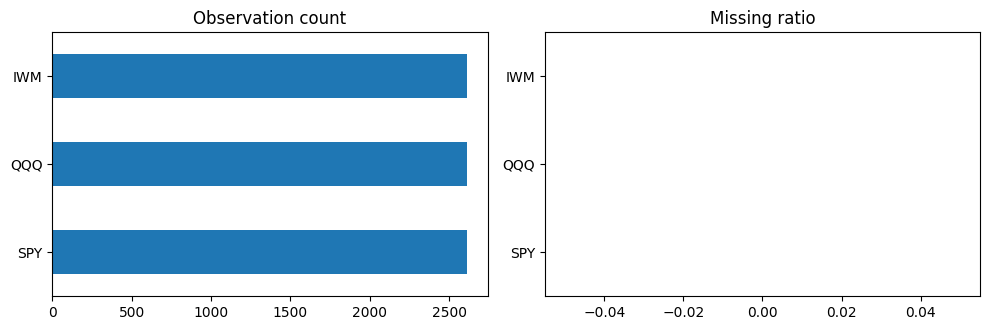

In [3]:
audit_view = audit.set_index("ticker")[["observations", "missing_ratio"]]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
audit_view["observations"].sort_values().plot(kind="barh", ax=axes[0], color="tab:blue", title="Observation count")
audit_view["missing_ratio"].sort_values().plot(kind="barh", ax=axes[1], color="tab:orange", title="Missing ratio")
for ax in axes:
    ax.set_ylabel("")
plt.tight_layout()
plt.show()


In [4]:
features = walkforward_decompose(prices, method="STL", period=63, train_window=252, step=21)
entries, exits = trend_pullback_signals(prices, features)
result = backtest_long_short_signals(prices, entries, exits, fee_bps=1.0, slippage_bps=2.0)
result.stats_frame()

,value
total_return,0.237548
cagr,0.020775
volatility,0.145564
sharpe,0.214458
max_drawdown,-0.394659
calmar,0.052641
hit_rate,0.222818
average_turnover,0.023864
average_gross_exposure,0.397397
fee_bps,1.000000


## Visualization: walk-forward coverage and risk

Feature availability, equity, and drawdown are plotted as direct validation artifacts.

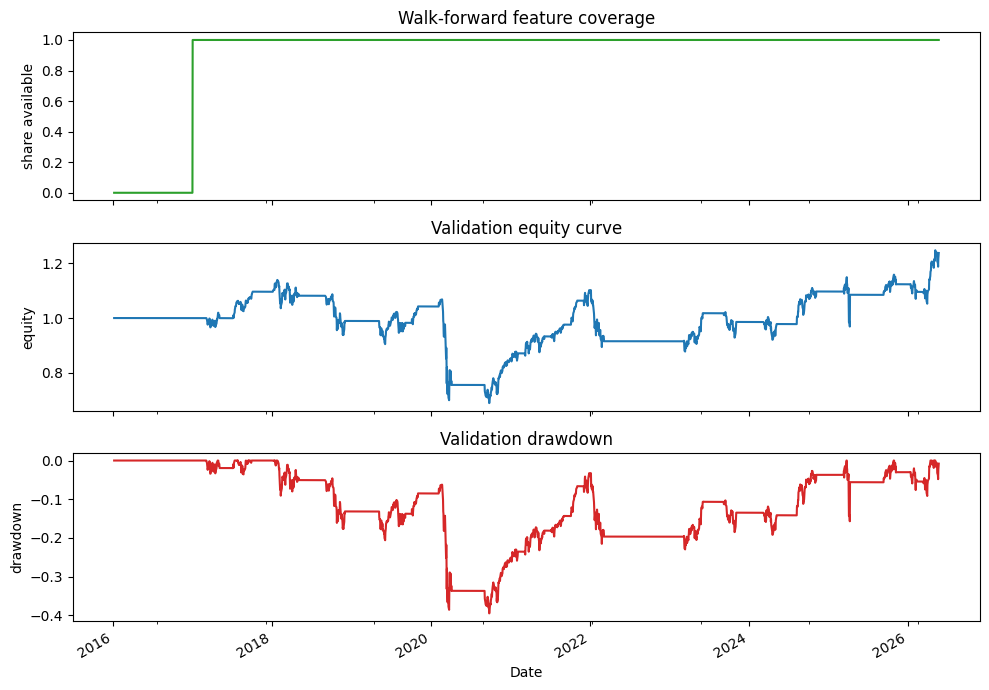

In [5]:
feature_coverage = features["trend_slope"].notna().mean(axis=1)
drawdown = result.equity / result.equity.cummax() - 1.0
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
feature_coverage.plot(ax=axes[0], color="tab:green", title="Walk-forward feature coverage")
result.equity.plot(ax=axes[1], title="Validation equity curve")
drawdown.plot(ax=axes[2], color="tab:red", title="Validation drawdown")
axes[0].set_ylabel("share available")
axes[1].set_ylabel("equity")
axes[2].set_ylabel("drawdown")
plt.tight_layout()
plt.show()


In [6]:
validation_summary = pd.DataFrame({
    "check": [
        "real data downloaded",
        "data audit generated",
        "walk-forward decomposition used",
        "positions shifted one bar",
        "turnover costs charged",
        "metrics reported",
    ],
    "status": [True, True, True, True, True, True],
})
validation_summary

,check,status
0,real data downloaded,True
1,data audit generated,True
2,walk-forward decomposition used,True
3,positions shifted one bar,True
4,turnover costs charged,True
5,metrics reported,True


Production next steps: add licensed point-in-time data, train/validation/test splits, richer execution model, bootstrap uncertainty, borrow and financing, FX handling, and failed-run reporting.